<h1>PARTE 1: Regresion Logistica </h1>



<h2> 1-Tratamiento base</h2>




In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


In [42]:
df=pd.read_excel("C:\\Users\\fatan\\Downloads\\GiveMeCredit.xlsx")
df[:10]


,Default,Revolvente,Edad,Veces_B1,Deuda_Ingreso,Ingreso,Cuentas_Abiertas,Veces_B3,Cuentas_Abiertas_Mayores,Veces_B2,Dependientes
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
5,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
6,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
7,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
8,0,0.644226,30,0,0.309476,2500.0,5,0,0,0,0.0
9,0,0.018798,51,0,0.531529,6501.0,7,0,2,0,2.0


<h5>Nulos & NA</h5>

In [3]:
pd.isna(df).sum()

Default                         0
Revolvente                      0
Edad                            0
Veces_B1                        0
Deuda_Ingreso                   0
Ingreso                     23718
Cuentas_Abiertas                0
Veces_B3                        0
Cuentas_Abiertas_Mayores        0
Veces_B2                        0
Dependientes                 3157
dtype: int64

In [7]:
pd.isnull(df).sum() 

Default                         0
Revolvente                      0
Edad                            0
Veces_B1                        0
Deuda_Ingreso                   0
Ingreso                     23718
Cuentas_Abiertas                0
Veces_B3                        0
Cuentas_Abiertas_Mayores        0
Veces_B2                        0
Dependientes                 3157
dtype: int64

In [70]:
##Filtrando nulos
df_nulos = df[df.isnull().any(axis=1)]
print(df_nulos)

        Default  Revolvente  Edad  Veces_B1  Deuda_Ingreso  Ingreso  \
5             0    0.305682    57         0         5710.0      NaN   
7             0    0.116951    27         0           46.0      NaN   
14            0    0.061086    78         0         2058.0      NaN   
26            0    0.083418    62         0          977.0      NaN   
35            0    0.072898    81         0           75.0      NaN   
...         ...         ...   ...       ...            ...      ...   
120001        0    1.000000    27         0           98.0      NaN   
120002        0    0.977899    63         0          517.0      NaN   
120014        0    0.037548    84         0           25.0      NaN   
120018        0    0.871976    50         0         4132.0      NaN   
120020        0    0.246044    58         0         3870.0      NaN   

        Cuentas_Abiertas  Veces_B3  Cuentas_Abiertas_Mayores  Veces_B2  \
5                      8         0                         3         0   

In [25]:
#Ingresos igual a 0
cuenta_ingreso_cero = (df["Ingreso"] == 0).sum()
print("Cantidad de ingresos iguales a 0:", cuenta_ingreso_cero)

Cantidad de ingresos iguales a 0: 1337


<h5>Cambios realizados antes de correr el modelo:</h5>
<ul>
  <li>Los valores <strong>NA</strong> en la variable <strong>Deficientes</strong> se reemplazaron por <strong>0</strong>.</li>
  <li>Los valores <strong>NA</strong> en la variable <strong>Ingresos</strong> se imputaron con el <strong>promedio</strong> de dicha variable.</li>
</ul>


In [60]:
##Manipulacion variable:Dependiente 
df.Dependientes.value_counts(1)
df['Dependientes'] = df['Dependientes'].fillna(0)
pd.isnull(df).sum()


Default                         0
Revolvente                      0
Edad                            0
Veces_B1                        0
Deuda_Ingreso                   0
Ingreso                     23718
Cuentas_Abiertas                0
Veces_B3                        0
Cuentas_Abiertas_Mayores        0
Veces_B2                        0
Dependientes                    0
dtype: int64

In [61]:
##Manipulando variable:Ingreso
df_null=df.copy()
df_null['Ingreso'].fillna(df['Ingreso'].mean(), inplace=True)
df_null

,Default,Revolvente,Edad,Veces_B1,Deuda_Ingreso,Ingreso,Cuentas_Abiertas,Veces_B3,Cuentas_Abiertas_Mayores,Veces_B2,Dependientes
0,1,0.766127,45,2,0.802982,9120.000000,13,0,6,0,2.0
1,0,0.658180,38,1,0.085113,3042.000000,2,1,0,0,0.0
2,0,0.233810,30,0,0.036050,3300.000000,5,0,0,0,0.0
3,0,0.907239,49,1,0.024926,63588.000000,7,0,1,0,0.0
4,0,0.213179,74,0,0.375607,3500.000000,3,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
120018,0,0.871976,50,0,4132.000000,6666.476164,11,0,1,0,3.0
120019,0,0.040674,74,0,0.225131,2100.000000,4,0,1,0,0.0
120020,0,0.246044,58,0,3870.000000,6666.476164,18,0,1,0,0.0
120021,0,0.000000,30,0,0.000000,5716.000000,4,0,0,0,0.0


<h5>Conteos</h5>

In [46]:
for col in df_null.columns:
    print(f'\n📊 Variable: {col}')
    display(pd.concat(
        [df_null[col].value_counts(), df_null[col].value_counts(1)],
        axis=1,
        keys=['Conteo', 'Proporción']
    ))


📊 Variable: Default


,Conteo,Proporción
0,111992,0.933088
1,8031,0.066912



📊 Variable: Revolvente


,Conteo,Proporción
0.000000,8666,0.072203
1.000000,8170,0.068070
1.000000,15,0.000125
0.950100,7,0.000058
0.007984,6,0.000050
...,...,...
0.070147,1,0.000008
0.112160,1,0.000008
0.060789,1,0.000008
0.046649,1,0.000008



📊 Variable: Edad


...

,Conteo,Proporción
0,44929,0.374337
1,41931,0.349358
2,25200,0.209960
3,5038,0.041975
4,1749,0.014572
5,543,0.004524
6,258,0.002150
7,132,0.001100
8,76,0.000633
9,59,0.000492



📊 Variable: Veces_B2


,Conteo,Proporción
0,113945,0.949360
1,4597,0.038301
2,893,0.007440
3,244,0.002033
98,207,0.001725
4,84,0.000700
5,27,0.000225
6,13,0.000108
7,8,0.000067
8,2,0.000017



📊 Variable: Dependientes


,Conteo,Proporción
0.0,72715,0.605842
1.0,20946,0.174517
2.0,15687,0.130700
3.0,7607,0.063380
4.0,2282,0.019013
5.0,600,0.004999
6.0,125,0.001041
7.0,38,0.000317
8.0,14,0.000117
10.0,4,0.000033


<h5>Express_ Statistics</h5>

In [47]:
for col in df_null.columns:
    print(f"--- {col} ---")
    print(df_null[col].describe())
    print("\n")

--- Default ---
count    120023.000000
mean          0.066912
std           0.249871
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Default, dtype: float64


--- Revolvente ---
count    120023.000000
mean          6.210002
std         265.901762
min           0.000000
25%           0.029937
50%           0.155498
75%           0.561483
max       50708.000000
Name: Revolvente, dtype: float64


--- Edad ---
count    120023.000000
mean         52.320947
std          14.769435
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: Edad, dtype: float64


--- Veces_B1 ---
count    120023.000000
mean          0.415837
std           4.134231
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: Veces_B1, dtype: float64


--- Deuda_Ingreso ---
count    120023.000000
mean        355.462513
st

<h5>Variables</h5>

<p>
  Tomando en cuenta que variables como: <strong>Veces_B1</strong>, <strong>Veces_B2</strong>, <strong>Veces_B3</strong>, 
  <strong>Cuentas_Abiertas</strong>, <strong>Cuentas_Abiertas_Mayores</strong> y <strong>Dependientes</strong>, independientemente de que sean numéricas, 
  no presentan cantidades significativas para ser tratadas como variables continuas. 
  Se observa que en varios puntos su proporción disminuye notablemente, 
  lo cual reduce su representatividad dentro del conjunto de datos. 
  Por tanto, se decide transformar su formato a <strong>variables categóricas</strong>, categorizando tomando en cuenta los <strong>cuantiles</strong>.
</p>


In [62]:
#Dependientes:
df_null['Dependientes_Category'] = np.where(df_null['Dependientes'].astype(float) == 0, 'Ninguno',
                                   np.where(df_null['Dependientes'].astype(float) == 1, 'Uno',
                                   np.where(df_null['Dependientes'].astype(float) == 2, 'Dos',
                                   np.where(df_null['Dependientes'].astype(float).between(3, 4), 'Varios',
                                            'Muchos'))))


In [63]:
#Cuentas_Abiertas:
df_null['Cuentas_Abiertas_Category'] = np.where(df_null['Cuentas_Abiertas'] < 5, 'Muy bajo',
                                        np.where(df_null['Cuentas_Abiertas'] < 8, 'Bajo',
                                        np.where(df_null['Cuentas_Abiertas'] < 11, 'Medio',
                                                 'Alto')))

In [64]:
#Cuentas_Abiertas_Mayores:
df_null['Cuentas_Abiertas_Mayores_Category'] = np.where(df_null['Cuentas_Abiertas_Mayores'] == 0, 'Ninguna',
                                                np.where(df_null['Cuentas_Abiertas_Mayores'] == 1, 'Una',
                                                np.where(df_null['Cuentas_Abiertas_Mayores'] == 2, 'Pocas',
                                                np.where(df_null['Cuentas_Abiertas_Mayores'].between(3, 4), 'Varias',
                                                         'Muchas'))))


In [84]:
#Veces
veces_cols = ["Veces_B1","Veces_B2", "Veces_B3","Default"]

for col in veces_cols:
    df_null[col] = df_null[col].astype(str)

df_null = df_null.replace({
    "Veces_B1": { str(x): "+4" for x in range(4,100)},
    "Veces_B2": { str(x): "+4" for x in range(4,100)},
    "Veces_B3": { str(x): "+4" for x in range(4,100)}
}, inplace=False)  

In [67]:
df_null

,Default,Revolvente,Edad,Veces_B1,Deuda_Ingreso,Ingreso,Cuentas_Abiertas,Veces_B3,Cuentas_Abiertas_Mayores,Veces_B2,Dependientes,Dependientes_Category,Cuentas_Abiertas_Category,Cuentas_Abiertas_Mayores_Category
0,1,0.766127,45,2,0.802982,9120.000000,13,0,6,0,2.0,Dos,Alto,Muchas
1,0,0.658180,38,1,0.085113,3042.000000,2,1,0,0,0.0,Ninguno,Muy bajo,Ninguna
2,0,0.233810,30,0,0.036050,3300.000000,5,0,0,0,0.0,Ninguno,Bajo,Ninguna
3,0,0.907239,49,1,0.024926,63588.000000,7,0,1,0,0.0,Ninguno,Bajo,Una
4,0,0.213179,74,0,0.375607,3500.000000,3,0,1,0,1.0,Uno,Muy bajo,Una
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120018,0,0.871976,50,0,4132.000000,6666.476164,11,0,1,0,3.0,Varios,Alto,Una
120019,0,0.040674,74,0,0.225131,2100.000000,4,0,1,0,0.0,Ninguno,Muy bajo,Una
120020,0,0.246044,58,0,3870.000000,6666.476164,18,0,1,0,0.0,Ninguno,Alto,Una
120021,0,0.000000,30,0,0.000000,5716.000000,4,0,0,0,0.0,Ninguno,Muy bajo,Ninguna


In [96]:
var_num = [x for x in df_null.columns if df_null.dtypes[x]!='O']
print(var_num)

var_cat = [x for x in df_null.columns if df_null.dtypes[x]=='O'if x not in ['Default']]
print(var_cat)

['Revolvente', 'Edad', 'Deuda_Ingreso', 'Ingreso', 'Cuentas_Abiertas', 'Cuentas_Abiertas_Mayores', 'Dependientes']
['Veces_B1', 'Veces_B3', 'Veces_B2', 'Dependientes_Category', 'Cuentas_Abiertas_Category', 'Cuentas_Abiertas_Mayores_Category']


In [69]:
for col in df_null.columns:
    print(f'\n📊 Variable: {col}')
    display(pd.concat(
        [df_null[col].value_counts(), df_null[col].value_counts(1)],
        axis=1,
        keys=['Conteo', 'Proporción']
    ))


📊 Variable: Default


,Conteo,Proporción
0,111992,0.933088
1,8031,0.066912



📊 Variable: Revolvente


,Conteo,Proporción
0.000000,8666,0.072203
1.000000,8170,0.068070
1.000000,15,0.000125
0.950100,7,0.000058
0.007984,6,0.000050
...,...,...
0.070147,1,0.000008
0.112160,1,0.000008
0.060789,1,0.000008
0.046649,1,0.000008



📊 Variable: Edad


...

,Conteo,Proporción
Ninguno,72715,0.605842
Uno,20946,0.174517
Dos,15687,0.130700
Varios,9889,0.082393
Muchos,786,0.006549



📊 Variable: Cuentas_Abiertas_Category


,Conteo,Proporción
Alto,34564,0.287978
Bajo,31827,0.265174
Medio,26886,0.224007
Muy bajo,26746,0.222841



📊 Variable: Cuentas_Abiertas_Mayores_Category


,Conteo,Proporción
Ninguna,44929,0.374337
Una,41931,0.349358
Pocas,25200,0.209960
Varias,6787,0.056547
Muchas,1176,0.009798


<h2>2-Bivariados</h2>


<p>
  Nuestra variable objetivo es <strong>categórica</strong>, por tanto las relaciones serán 
  <strong>categórica-categórica</strong> o <strong>categórica-numérica</strong>.
</p>


<h5>Tabla WoE</h5>

In [86]:
def WoE_TAB(x, y, data):
    W_T= pd.crosstab(data[x], data[y])
    aux= W_T.apply(lambda x: x/x.sum(), axis= 0)
    aux.rename(columns= {aux.columns[0]: 'P_'+aux.columns[0], aux.columns[1]: 'P_'+aux.columns[1]}, inplace=True)
    W_T= pd.concat([W_T, aux], axis= 1)
    W_T['WoE']= np.log( np.clip(W_T[W_T.columns[2]]/W_T[W_T.columns[3]], 1E-15, 1E+3) )
    W_T['IV']= W_T.WoE*(W_T[W_T.columns[2]]-W_T[W_T.columns[3]])
    return(W_T)

In [178]:
for var in var_cat:
    if var != 'Default':
        print(f"## Variable: {var}\n")
        tabla = WoE_TAB(x=var, y='Default', data=df_null)
        print(tabla)
        print("\n---\n")


## Variable: Veces_B1

Default       0     1       P_0       P_1       WoE        IV
Veces_B1                                                     
+4          672   591  0.006000  0.073590 -2.506676  0.169425
0         96814  4024  0.864472  0.501058  0.545397  0.198205
1         10926  1932  0.097561  0.240568 -0.902529  0.129068
2          2667   989  0.023814  0.123148 -1.643103  0.163215
3           913   495  0.008152  0.061636 -2.022940  0.108195

---

## Variable: Veces_B3

Default        0     1       P_0       P_1       WoE        IV
Veces_B3                                                      
+4           257   424  0.002295  0.052795 -3.135776  0.158359
0         108071  5281  0.964989  0.657577  0.383555  0.117909
1           2801  1393  0.025011  0.173453 -1.936602  0.287473
2            641   622  0.005724  0.077450 -2.605029  0.186849
3            222   311  0.001982  0.038725 -2.972234  0.109208

---

## Variable: Veces_B2

Default        0     1       P_0       P_1  

In [180]:
for var in var_cat:
    if var != 'Default':
        print(f"## Variable: {var}\n")
        tabla = WoE_TAB(x=var, y='Default', data=df_null)
        print(tabla.IV.sum())
        print("\n---\n")

## Variable: Veces_B1

0.7681076745453371

---

## Variable: Veces_B3

0.8597978108409794

---

## Variable: Veces_B2

0.5913818800337393

---

## Variable: Dependientes_Category

0.035188714675357204

---

## Variable: Cuentas_Abiertas_Category

0.042851883195758056

---

## Variable: Cuentas_Abiertas_Mayores_Category

0.05735116736188852

---



<p>
  Con base en los valores de <strong>WOE</strong> calculados y apoyándonos en el <strong>Information Value (IV)</strong>, observamos que las variables <strong>Veces_B1</strong>, <strong>Veces_B2</strong> y <strong>Veces_B3</strong> son fuertes predictores para el modelo. En particular, la categoría <strong>+4</strong> presenta un <em>WOE negativo</em>, lo que indica una mayor proporción de clientes con <strong>default (1)</strong> en comparación con los clientes sin default (<strong>0</strong>), es decir, un mayor riesgo de incumplimiento.
</p>

<p>
  Asimismo, la variable <strong>Dependientes</strong> muestra una relación similar, aunque menos pronunciada, pero con un valor significativo que merece atención, ya que varios valores resaltan en esta variable.
</p>

<p>
  Las demás variables también muestran alguna presencia en el modelo, pero su representación es menor en comparación con las mencionadas inicialmente.
</p>

<p>
  Finalmente, el <strong>IV</strong> respalda esta conclusión al medir el poder predictivo de cada variable. Aunque algunas variables presentan un valor de IV muy fuerte, variables como <strong>Cuentas_Abiertas</strong> y <strong>Dependientes</strong> se posicionan en un rango de poder predictivo débil, lo que sugiere que aportan menos información para la predicción del default.
</p>


<h2>3-Categoricas->Numericas</h2>


In [95]:
dict(WoE_TAB(x = "Cuentas_Abiertas_Category" , y = 'Default', data = df_null).reset_index().iloc[:,[0,5]].values)

{'Alto': 0.046212318104747054,
 'Bajo': 0.1336044369709116,
 'Medio': 0.1992770368998315,
 'Muy bajo': -0.33864600812988827}

In [97]:
cat_woe =  {i: dict(WoE_TAB(x = i, y = 'Default', data = df_null).reset_index().iloc[:,[0,5]].values) for i in var_cat}
cat_woe

{'Veces_B1': {'+4': -2.5066760638491474,
  '0': 0.5453967921604328,
  '1': -0.9025288527829992,
  '2': -1.6431031944068968,
  '3': -2.0229402689399207},
 'Veces_B3': {'+4': -3.135775757302937,
  '0': 0.38355455784304276,
  '1': -1.9366015854858962,
  '2': -2.6050290227847084,
  '3': -2.9722339172731536},
 'Veces_B2': {'+4': -2.951689469270117,
  '0': 0.28524087876382115,
  '1': -1.8318750860025932,
  '2': -2.6060009883954716,
  '3': -2.9491492891147315},
 'Dependientes_Category': {'Dos': -0.2031541564483979,
  'Muchos': -0.4575297841468384,
  'Ninguno': 0.15306576684816192,
  'Uno': -0.10900297026867013,
  'Varios': -0.35556334602740586},
 'Cuentas_Abiertas_Category': {'Alto': 0.046212318104747054,
  'Bajo': 0.1336044369709116,
  'Medio': 0.1992770368998315,
  'Muy bajo': -0.33864600812988827},
 'Cuentas_Abiertas_Mayores_Category': {'Muchas': -0.8978471030222136,
  'Ninguna': -0.22430931437555318,
  'Pocas': 0.1748903231107018,
  'Una': 0.24283644876616609,
  'Varias': -0.0838927246634

In [99]:
var_num2=[x for x in df_null.columns if df_null.dtypes[x]!='O' if x not in ['Cuentas_Abiertas', 'Cuentas_Abiertas_Mayores', 'Dependientes']]
var_num2

['Revolvente', 'Edad', 'Deuda_Ingreso', 'Ingreso']

<h2>4-Entrenamiento y Validacion</h2>

In [101]:
from sklearn.model_selection import train_test_split

x_ent, x_val, y_ent, y_val = train_test_split(df_null[var_num2+var_cat].replace(cat_woe), 
                                              df_null.Default,
                                              train_size=0.8,
                                              random_state=20,
                                              stratify=df_null.Default 
                                             )

<h2>5-Logistic regression</h2>

In [102]:
from sklearn.linear_model import LogisticRegression

## Objeto
modelo_rlog = LogisticRegression(max_iter=500_000, C=4, penalty='l2', solver='liblinear', class_weight ='balanced')

modelo_rlog.fit(x_ent, y_ent)

## Soore
print('Score entrenamiento:', modelo_rlog.score(x_ent, y_ent))
print('Score validación:', modelo_rlog.score(x_val, y_val))

Score entrenamiento: 0.8360828178049949
Score validación: 0.8349927098521142


<p>
  El modelo logró una exactitud del 83 % sobre los datos de entrenamiento.
  Al evaluarlo con datos nuevos, también obtuvo una exactitud del 83 %, lo que sugiere que generaliza adecuadamente
  y no presenta signos evidentes de sobreajuste.
</p>


<h2>6-Matrices de confusion</h2>

In [149]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

pred_ent = modelo_rlog.predict(x_ent)
pred_val = modelo_rlog.predict(x_val)

<h5>Base de entrenamiento</h5>

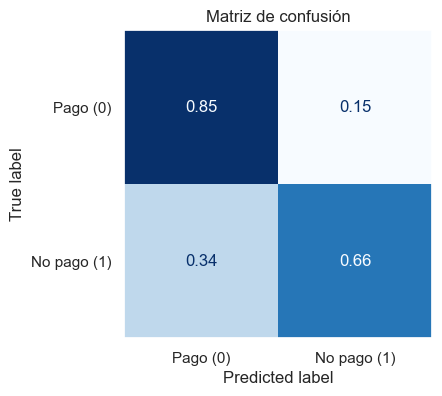

In [128]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax= plt.subplots(figsize= (4, 4))
ConfusionMatrixDisplay.from_predictions(y_ent, pred_ent,
                                        display_labels=["Pago (0)", "No pago (1)"],
                                        cmap = plt.cm.Blues,  # Paleta de colores
                                        normalize = 'true',   
                                        values_format = '.2f',
                                        ax = ax,
                                        colorbar = False
                                       )

plt.title('Matriz de confusión')
plt.grid(linewidth= 0)
plt.show()

In [130]:
display(pd.crosstab(y_ent, pred_ent))

col_0,0,1
Default,,
0,76050,13543
1,2196,4229


<h5>Base de validacion</h5>

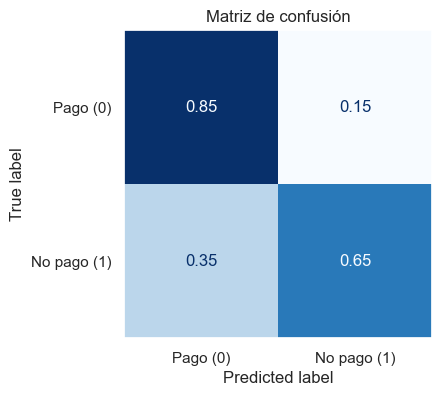

In [132]:
fig, ax= plt.subplots(figsize= (4, 4))
ConfusionMatrixDisplay.from_predictions(y_val, pred_val,
                                        display_labels=["Pago (0)", "No pago (1)"],
                                        cmap = plt.cm.Blues,  # Paleta de colores
                                        normalize = 'true',   # 'true' para que la matriz muestre porcentajes
                                        values_format = '.2f',
                                        ax = ax,
                                        colorbar = False
                                       )

plt.title('Matriz de confusión')
plt.grid(linewidth= 0)
plt.show()

In [133]:
display(pd.crosstab(y_val, pred_val))

col_0,0,1
Default,,
0,18997,3402
1,559,1047


<h5>Interpretación de Matriz de Confusión</h5>
<p>Sea:</p>
<ul>
    <li><strong>0 = Pagó</strong></li>
    <li><strong>1 = No pagó</strong></li>
</ul>
<p>Tenemos:</p>
<ul>
    <li>Pagó y fue clasificado como Pagó: 85%</li>
    <li>Pagó y fue clasificado como No Pagó: 15%</li>
    <li>No Pagó y fue clasificado como No Pagó: 65%</li>
    <li>No Pagó y fue clasificado como Pagó: 35%</li>
</ul>



<h2>7-Interpretacion parametros</h2>

In [170]:
pd.DataFrame({'Variable': ['B0']+list(x_ent.columns),
              'Beta': modelo_rlog.intercept_.tolist() + modelo_rlog.coef_[0].tolist(),
              'Exp_Beta': [np.exp(x) for x in modelo_rlog.intercept_.tolist() + modelo_rlog.coef_[0].tolist()]
             })

,Variable,Beta,Exp_Beta
0,B0,1.426703,4.164944
1,Revolvente,-0.000086,0.999914
2,Edad,-0.026407,0.973939
3,Deuda_Ingreso,-0.000004,0.999996
4,Ingreso,-0.000014,0.999986
5,Veces_B1,-0.766959,0.464423
6,Veces_B3,-0.750738,0.472018
7,Veces_B2,-0.606022,0.545517
8,Dependientes_Category,-0.575992,0.562147
9,Cuentas_Abiertas_Category,-0.131759,0.876552


<img src="Captura de pantalla 2025-06-11 182930.png" alt="Parametros a analizar" width="500">

<p><strong>Edad:</strong> Un odds ratio de 0.9739 indica que por cada año adicional, la probabilidad de no pago es aproximadamente 1.03 veces menor (o un 2.6% menos) que la anterior.</p>

<p><strong>Deuda_Ingreso:</strong> Un odds ratio cercano a 1 (0.999996) significa que esta variable casi no cambia la probabilidad de no pago.</p>

<p><strong>Veces_B1:</strong> Un odds ratio de 0.4644 indica que la probabilidad de no pago es aproximadamente 2.15 veces menor (1/0.4644 ≈ 2.15) para un aumento en esta variable, es decir, reduce el riesgo de incumplimiento.</p>

<p><strong>Cuentas_Abiertas_Mayores_Category:</strong> Un odds ratio de 0.4602 significa que la probabilidad de no pago es cerca de 2.17 veces menor, mostrando también un efecto protector contra el incumplimiento.</p>


<h5>WoE</h5>

In [90]:
probas = pd.DataFrame(modelo_rlog.predict_proba(x_ent), columns = ['P_Pago', 'P_NO_Pago'])
probas['Real'] = y_ent.reset_index(drop=True)
probas['Prob_P_Cat'] = np.ceil(probas.P_NO_Pago*20)/20
probas

,P_Pago,P_NO_Pago,Real,Prob_P_Cat
0,0.080514,0.919486,1,0.95
1,0.870460,0.129540,0,0.15
2,0.317385,0.682615,0,0.70
3,0.158122,0.841878,0,0.85
4,0.708676,0.291324,0,0.30
...,...,...,...,...
96013,0.781206,0.218794,0,0.25
96014,0.802109,0.197891,0,0.20
96015,0.426135,0.573865,0,0.60
96016,0.645867,0.354133,0,0.40


In [91]:
WoE_TAB(x='Prob_P_Cat', y='Real', data=probas)

Real,0,1,P_0,P_1,WoE,IV
Prob_P_Cat,,,,,,
0.05,71,0,0.000792,0.000000,6.907755,0.005474
0.10,668,5,0.007456,0.000778,2.259770,0.015090
0.15,6816,45,0.076077,0.007004,2.385285,0.164760
0.20,13092,151,0.146127,0.023502,1.827396,0.224085
0.25,14279,253,0.159376,0.039377,1.398075,0.167767
0.30,12836,350,0.143270,0.054475,0.966995,0.085865
0.35,10222,365,0.114094,0.056809,0.697320,0.039946
0.40,7816,350,0.087239,0.054475,0.470914,0.015429
0.45,5640,326,0.062951,0.050739,0.215661,0.002634


<p>
En general, se observa que a medida que aumenta la probabilidad de no pago estimada por el modelo, los valores de WoE tienden a ser más negativos. Esto indica que en dichas categorías hay una mayor proporción de clientes que no pagan (clase 1) en comparación con los que sí pagan (clase 0). 
</p>

<p>
Esta concordancia entre las probabilidades de no pago y los WoE negativos confirma que ambas métricas señalan grupos con mayor riesgo. En consecuencia, esto parecere ser un indicio de que el modelo discrimina adecuadamente entre clientes buenos y malos
</p>


<h2>8-Curva ROC</h2>

In [152]:
from sklearn.metrics import roc_curve, auc
import pandas as pd


probs = pd.DataFrame(modelo_rlog.predict_proba(x_ent), columns = ["Prob_Pago (0)", "Prob_No_Pago (1)"])
probs['Real'] = y_ent.reset_index(drop=True)


tfp, tvp, thresholds = roc_curve(probs['Real'], probs['Prob_No_Pago (1)'], pos_label="1")

# Área bajo la curva
roc_auc = auc(tfp, tvp)

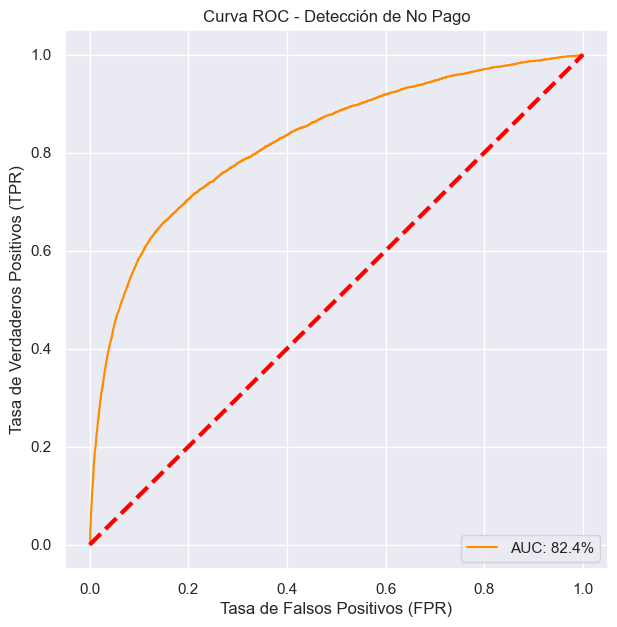

In [153]:
## Gráfica de la curva ROC

plt.figure(figsize=(7, 7))
plt.plot(tfp, tvp, color='darkorange', label=f'AUC: {roc_auc:.1%}')
plt.plot([0, 1], [0, 1], color= "red", lw=3, linestyle='--')
plt.legend(loc= 4)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Detección de No Pago')
plt.show()

<p>Observamos que el área bajo la curva (AUC) de nuestra curva ROC es del <strong>82.4%</strong>. Esto indica que, en términos generales, nuestro modelo tiene un buen desempeño para clasificar correctamente las observaciones.</p>


<h2>*Extra</h2>

<h5>Arbol</h5>

In [163]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(criterion = 'gini', random_state= 20, max_depth = 6, max_leaf_nodes = 20,
                               min_samples_split = 0.05, 
                               class_weight = {'1': .65, '0': .4})

arbol.fit(x_ent, y_ent)

#Scores
print('Score con base de entrenamiento:', arbol.score(x_ent, y_ent))
print('Score con base de validación:', arbol.score(x_val, y_val))


Score con base de entrenamiento: 0.934908038076194
Score con base de validación: 0.9356800666527807


<h5>Bosque</h5>

In [161]:
from sklearn.ensemble import RandomForestClassifier

bosque = RandomForestClassifier( n_estimators=150,
                                criterion='gini',
                                max_features='auto',   
                                max_depth=5,
                                bootstrap=True,
                                random_state=42,
                               min_weight_fraction_leaf=0.05,
                               max_samples=0.75
                               )

bosque.fit(x_ent, y_ent)

#Scores
print('Score con base de entrenamiento:', bosque.score(x_ent, y_ent))
print('Score con base de validación:', bosque.score(x_val, y_val))

Score con base de entrenamiento: 0.9330854631423274
Score con base de validación: 0.9330972714017913


<h5>Comparacion Curva ROC</h5>

In [164]:
#Regresión Logística
probs = pd.DataFrame(modelo_rlog.predict_proba(x_ent), columns = ["Prob_Pago (0)", "Prob_No_Pago (1)"])
probs['Real'] = y_ent.reset_index(drop=True)

tfp, tvp, a = roc_curve(probs['Real'], probs['Prob_No_Pago (1)'], pos_label="1")
roc_auc = auc(tfp, tvp)

#Arbol 
probs2 = pd.DataFrame(arbol.predict_proba(x_ent), columns = ["Prob_Pago (0)", "Prob_No_Pago (1)"])
probs2['Real'] = y_ent.reset_index(drop=True)

tfp2, tvp2, a =roc_curve(probs2['Real'], probs2['Prob_No_Pago (1)'], pos_label="1")
roc_auc2 = auc(tfp2, tvp2)

#Bosque
probs3 = pd.DataFrame(bosque.predict_proba(x_ent), columns = ["Prob_Pago (0)", "Prob_No_Pago (1)"])
probs3['Real'] = y_ent.reset_index(drop=True)

tfp3, tvp3, a = roc_curve(probs3['Real'], probs3['Prob_No_Pago (1)'], pos_label="1")
roc_auc3 = auc(tfp3, tvp3)




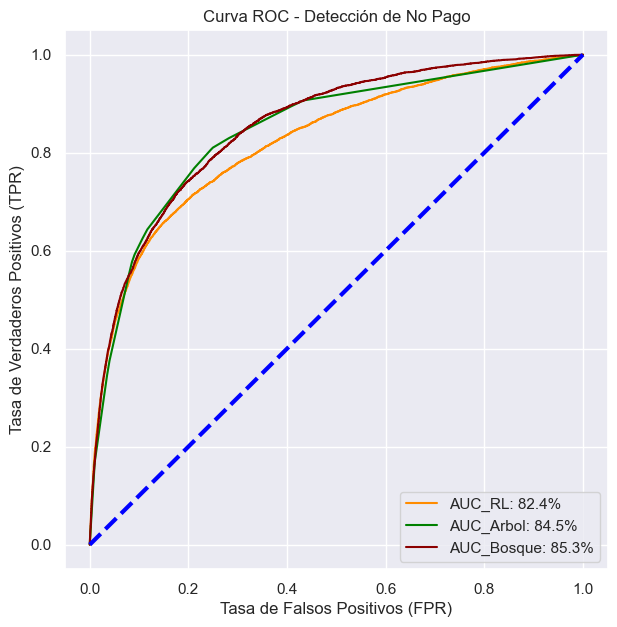

In [167]:
## Gráfica de la curva ROC
plt.figure(figsize=(7, 7))

plt.plot(tfp, tvp, color='darkorange', label=f'AUC_RL: {roc_auc:.1%}')
plt.plot(tfp2, tvp2, color='green', label=f'AUC_Arbol: {roc_auc2:.1%}')
plt.plot(tfp3, tvp3, color='darkred', label=f'AUC_Bosque: {roc_auc3:.1%}')

plt.plot([0, 1], [0, 1], color= "blue", lw=3, linestyle='--')
plt.legend(loc= 4)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Detección de No Pago')
plt.show()

<p>
A través de este análisis, observamos que el <strong>AUC</strong> del modelo basado en árboles aleatorios supera al de la regresión logística, lo cual también se refleja en los scores obtenidos. Esto podría sugerir que el modelo basado en árboles es una opción sólida para predecir nuestra variable objetivo, probablemente por su capacidad para manejar fácilmente variables categóricas, su robustez ante outliers, entre otras ventajas que la regresión logística, por sí sola, no pudo capturar.
</p>
